# Run 2nd level analysis with nilearn & visualize & report

needs all 1stlevel contrasts (both sessions)
main analysis: columns=["main","group", "session", "group x session"] + subject_list

In [5]:
##

import pandas as pd
from nilearn import plotting
import numpy as np
import matplotlib.pyplot as plt
import os.path as op

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'

orig_file = '/Users/mrenke/data/ds-stressrisk/group_assignmentList.csv'
group_mapping = pd.read_csv(orig_file)[['subject','group']]

In [6]:
con_n = 2
in_model_name = '1stlevel_Vhat-1'
ses = 1

In [7]:
#

scan_list = []
subject_list = []
session_list = []
group_list = []

for ses in [1,2]:
    for group in [0,1]:
        subList_fil = group_mapping[group_mapping['group'] == group]['subject'].tolist()
        for sub in subList_fil:
            con_file = op.join(bids_folder, 'derivatives', 'spm', f'sub-{sub:02d}',f'ses-{ses}', in_model_name, f'con_000{con_n}.nii')
            if op.isfile(con_file) and (sub not in (2 ,44)):
                scan_list.append(con_file)
                if ses == 1:
                    subject_list.append(sub)
                session_list.append(ses)
                group_list.append(group)
            else:
                print(f'sub-{sub:02d} ses-{ses} con-{con_n} not found')

group_array = np.array(group_list)
session_array = np.array(session_list) -1
group_session_int = group_array * session_array

print(len(scan_list))

sub-02 ses-1 con-2 not found
sub-44 ses-1 con-2 not found
sub-02 ses-2 con-2 not found
sub-44 ses-2 con-2 not found
96


In [8]:
n_subjects = int((len(scan_list)/2)) # len(subject_list)
subject_effect = np.vstack((np.eye(n_subjects), np.eye(n_subjects)))
np.shape(subject_effect)

(96, 48)

In [9]:
paired_design_matrix = pd.DataFrame(
    np.column_stack((np.ones(len(group_array)),group_array, session_array,group_session_int, subject_effect)),
    columns=["main","group", "session", "group x session"] + subject_list
)

In [159]:
# only interaction
paired_design_matrix = pd.DataFrame(
    np.column_stack((group_session_int, subject_effect)),
    columns=[ "group x session"] + subject_list
)

<AxesSubplot:label='conditions', ylabel='scan number'>

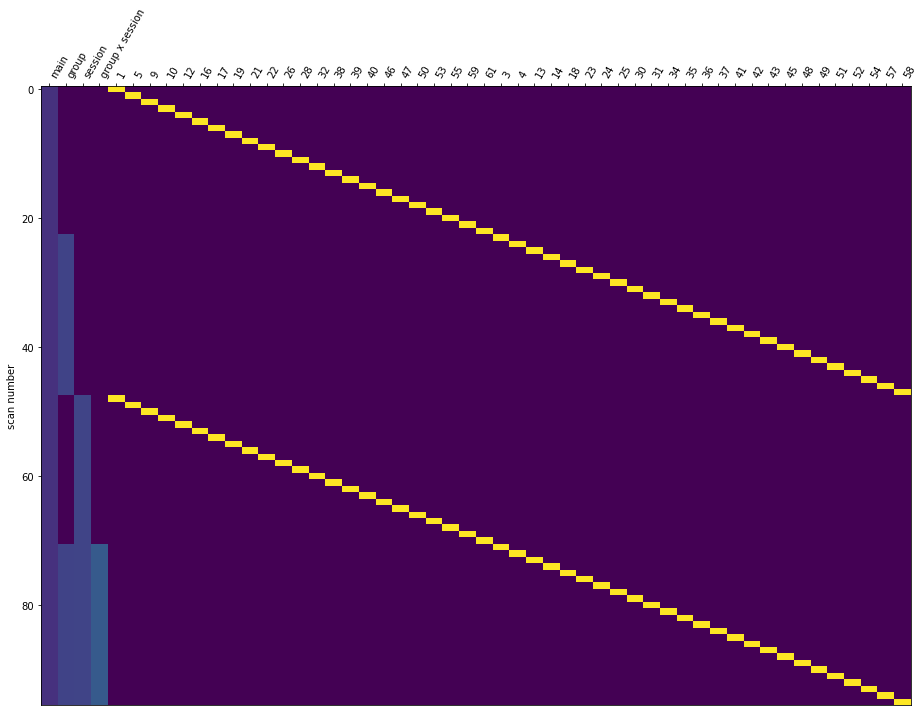

In [10]:
plotting.plot_design_matrix(paired_design_matrix)

In [11]:
from nilearn.glm.second_level import SecondLevelModel

model = SecondLevelModel(smoothing_fwhm=6.0, n_jobs=2)
model = model.fit(scan_list, design_matrix=paired_design_matrix)

In [12]:
contrast = 'main'#'group x session'
z_map = model.compute_contrast(second_level_contrast=contrast, output_type='z_score')

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_50255/503969457.py:3: DeprecationWarning: get_data() is deprecated in favor of get_fdata(), which has a more predictable return type. To obtain get_data() behavior going forward, use numpy.asanyarray(img.dataobj).

* deprecated from version: 3.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 5.0
  ax = sns.kdeplot(z_map.get_data().flatten(), color='k', alpha=0.5, fill=True)


(-1.0, 1.0)

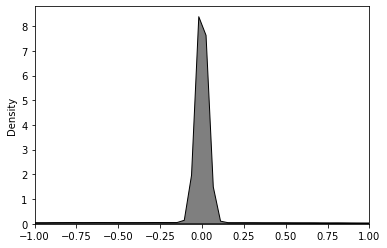

In [172]:
import seaborn as sns

ax = sns.kdeplot(z_map.get_data().flatten(), color='k', alpha=0.5, fill=True)
ax.set_xlim(-1,1)
#plt.hist(z_map.get_data().flatten().shape , color='k', alpha=0.5)

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()


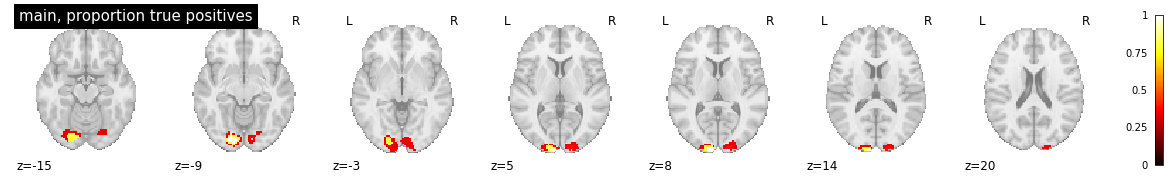

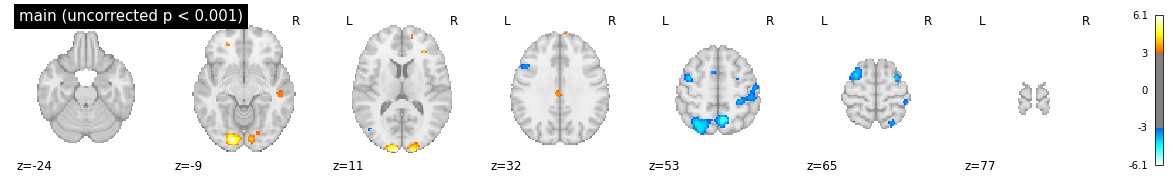

In [13]:
from scipy.stats import norm

p_val = 0.001
p001_uncorrected = norm.isf(p_val)

from nilearn.glm import cluster_level_inference

proportion_true_discoveries_img = cluster_level_inference(
    z_map, threshold=[3, 4, 5], alpha=0.05
)

from nilearn import plotting

plotting.plot_stat_map(
    proportion_true_discoveries_img,
    threshold=0.0,
    display_mode="z",
    vmax=1,
    colorbar=True,
    title=f"{contrast}, proportion true positives",
)

plotting.plot_stat_map(
    z_map,
    threshold=p001_uncorrected,
    colorbar=True,
    display_mode="z",
    title=f"{contrast} (uncorrected p < 0.001)",
)

plotting.show()


In [26]:
from nilearn import reporting

report_table = reporting.get_clusters_table(z_map,stat_threshold = p001_uncorrected, cluster_threshold=10, 
                             two_sided=False, min_distance=8.0)
report_table

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-9.0,-102.5,11.5,6.092502,13725
1,1a,-19.0,-87.5,-9.5,5.783280,
2,1b,13.5,-102.5,11.5,5.139536,
3,1c,11.0,-87.5,-9.5,4.099719,
4,2,3.5,25.0,14.5,3.950861,1068
5,2a,6.0,37.5,17.5,3.550196,
6,2b,-4.0,37.5,17.5,3.352459,
7,3,-4.0,-22.5,32.5,3.566305,281
8,4,11.0,35.0,56.5,3.435702,206
9,5,51.0,-25.0,-9.5,3.315909,225


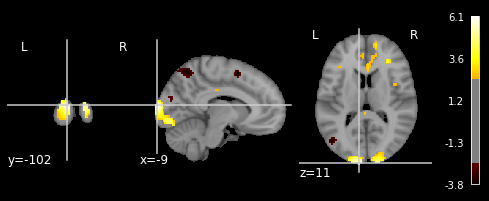

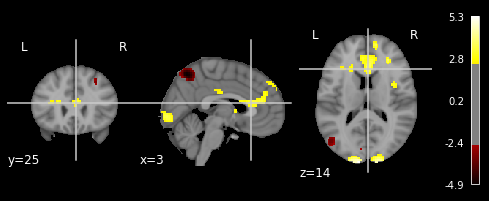

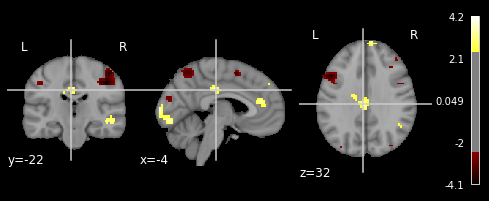

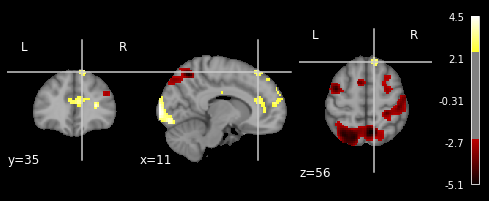

In [27]:
import nilearn.plotting as nipl 
import nibabel as nib
import matplotlib as mpl

anat_file = '/usr/local/fsl/data/standard/MNI152_T1_1mm_brain.nii.gz'
anat = nib.load(anat_file)

for cluster_id in range(1,5):
    coords = report_table[report_table['Cluster ID']==cluster_id][['X','Y','Z']].values.tolist()[0]
    display = nipl.plot_anat(anat_img = anat, cut_coords = (coords[0], coords[1], coords[2]))
    display.add_overlay(z_map, threshold = 2.5, colorbar=True, cmap = mpl.colormaps['hot'])   